In [ ]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/Group_Project/colab_models"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Group_Project
!pip install ultralytics

/content/drive/MyDrive/Group_Project


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 40.4/112.6 GB disk)


In [ ]:
# install pre-trained weight
%cd /content/drive/MyDrive/Group_Project
!wget https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8x.pt

/content/drive/MyDrive/Group_Project
--2025-09-29 09:10:28--  https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8x.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/bee960f1-3c07-412f-bbfb-a92f99a9dfb0?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-09-29T09%3A57%3A29Z&rscd=attachment%3B+filename%3Dyolov8x.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-09-29T08%3A56%3A48Z&ske=2025-09-29T09%3A57%3A29Z&sks=b&skv=2018-11-09&sig=BY8D46KvhT1NTfuh3WNjQigoFikTa9Xu1VjiSdQd75I%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1OTEzNzMyOCwibmJmIjoxNzU5MTM3MDI4LCJwYXRoIjoicmVs

In [ ]:
# training
%cd /content/drive/MyDrive/Group_Project
from ultralytics import YOLO

# Load a model
model = YOLO('yolov8x.pt')

# Train the model with 2 GPUs
results = model.train(data='/content/drive/MyDrive/Group_Project/data.yaml', epochs=50)

/content/drive/MyDrive/Group_Project
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Group_Project/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [ ]:
import torch
torch.save(model.state_dict(), f"{SAVE_DIR}/model_state.pt")
print("Saved to:", f"{SAVE_DIR}/model_state.pt")

Saved to: /content/drive/MyDrive/colab_models/model_state.pt


In [ ]:
# test custom trained weight
%cd /content/drive/MyDrive/Group_Project/dataset/images/val
!yolo task=detect mode=predict model="/content/drive/MyDrive/Group_Project/runs/detect/train5/weights/best.pt" name='result' source='/content/drive/MyDrive/Group_Project/dataset/images/val/0086CDWDO0WC3V8NNBO4.jpg'

/content/drive/MyDrive/Group_Project/dataset/images/val
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 68,133,198 parameters, 0 gradients, 257.4 GFLOPs

image 1/1 /content/drive/MyDrive/Group_Project/dataset/images/val/0086CDWDO0WC3V8NNBO4.jpg: 384x640 7 otos, 8 oto tais, 122.0ms
Speed: 3.5ms preprocess, 122.0ms inference, 200.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/Group_Project/dataset/images/val/runs/detect/result2
💡 Learn more at https://docs.ultralytics.com/modes/predict


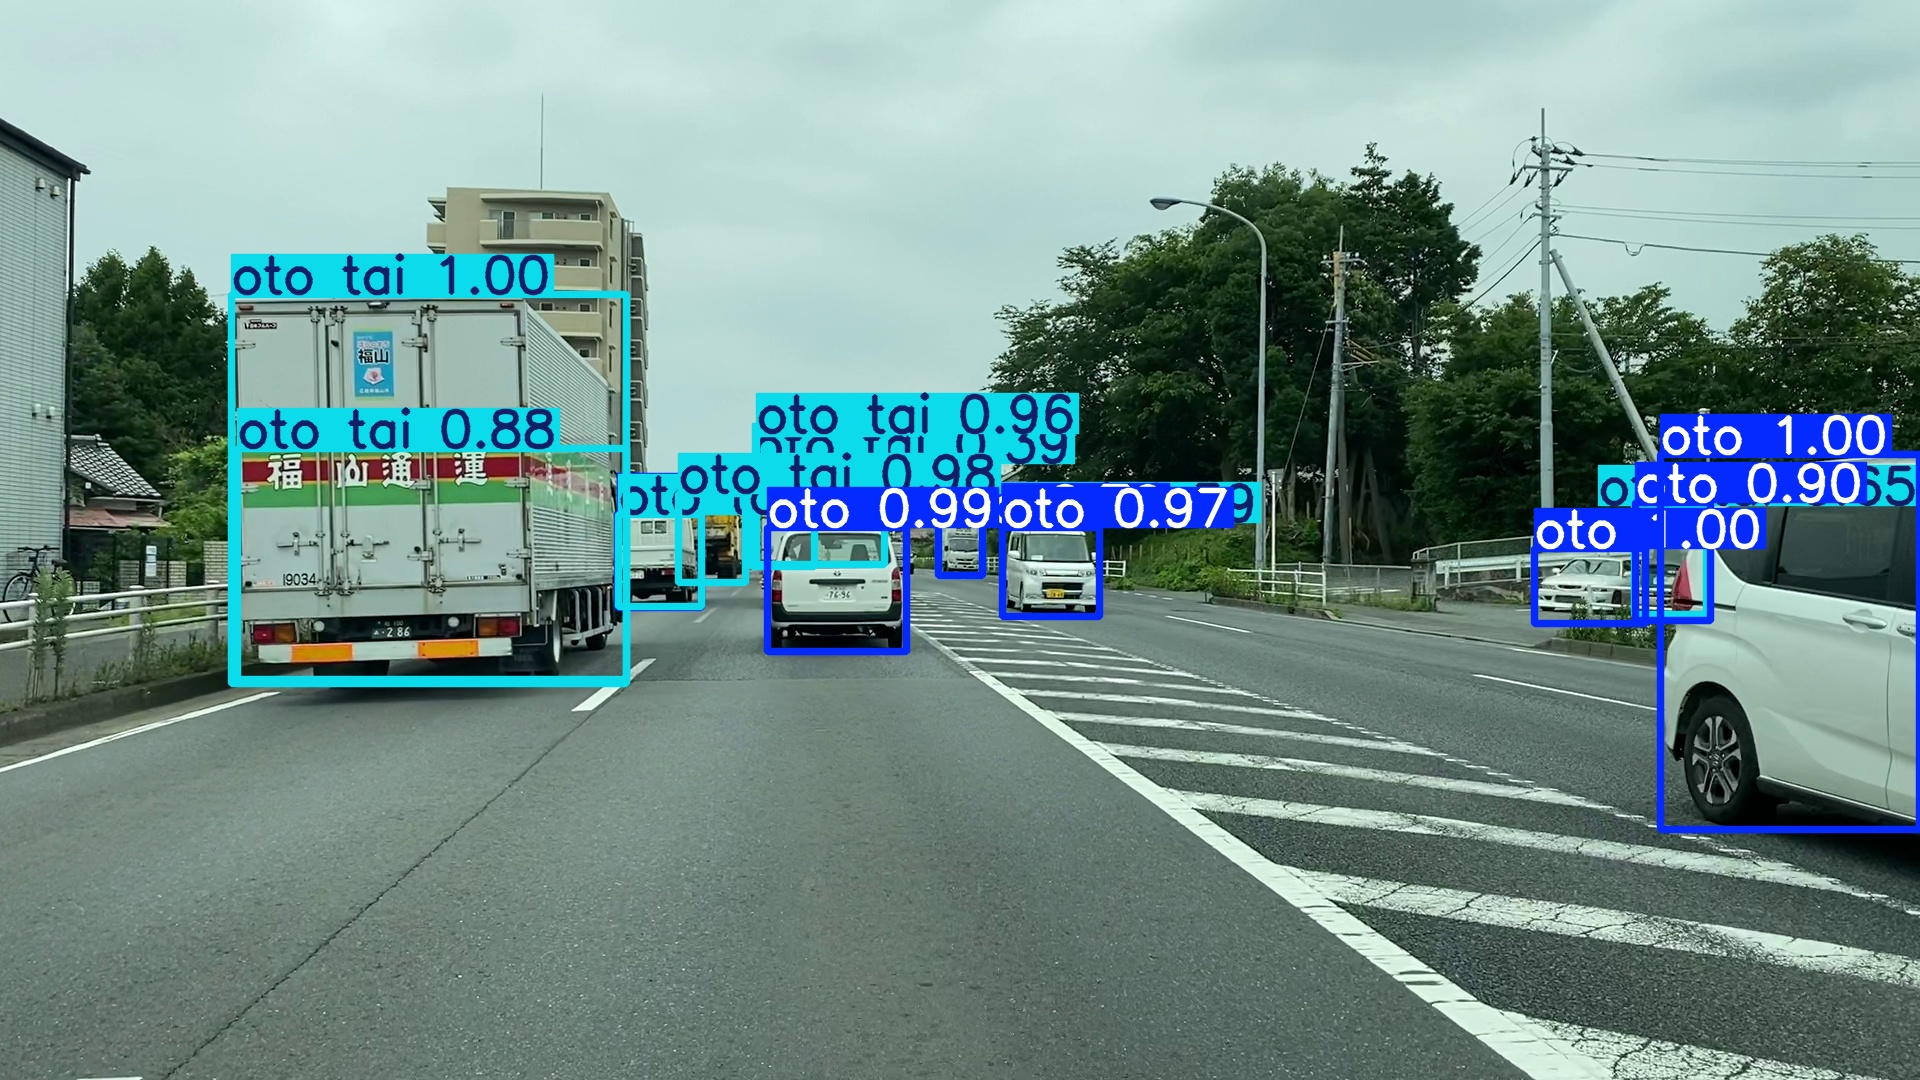

In [ ]:
from IPython.display import Image
Image(filename='/content/drive/MyDrive/Group_Project/dataset/images/val/runs/detect/result2/0086CDWDO0WC3V8NNBO4.jpg', width=640)

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:00
